In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , RobustScaler , OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer
from sklearn.metrics import ( accuracy_score, 
                            precision_score, 
                            recall_score,
                            f1_score,balanced_accuracy_score,
                            confusion_matrix,roc_curve,
                            roc_auc_score)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

In [2]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [3]:
df= pd.read_csv("data.csv")

In [6]:
# Convert empty string spaces to true numerical NaNs
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

# Cast the entire column to float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [4]:
df.drop(['customerID'], axis = 1,inplace=True)

In [5]:
# Map target values to binary flags
df['Churn'] = df['Churn'].replace({'No': 0, 'Yes': 1})


In [7]:
X = df.drop(columns = ['Churn'])
y=df['Churn']

In [8]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,stratify=y)

In [9]:
# 3. Explicitly group column categories
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols_ohe = ['PaymentMethod', 'Contract', 'InternetService']
cat_cols_le = list(set(X_train.columns) - set(num_cols) - set(cat_cols_ohe))

In [10]:
# 4. Construct distinct processing pipelines per feature type
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Safely handle missing values
    ('scaler', StandardScaler())
])

In [11]:
categorical_ohe_transformer = Pipeline(steps=[
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])
categorical_le_transformer = Pipeline(steps=[
    ('le', OrdinalEncoder()) # Safe replacement for LabelEncoder within structured pipelines
])
# 5. Bind your transformers into a single unified workspace
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('ohe', categorical_ohe_transformer, cat_cols_ohe),
        ('le', categorical_le_transformer, cat_cols_le)
    ]
)
from sklearn.calibration import CalibratedClassifierCV  # <-- Add this import

2 | Automated Model Training under Class Imbalance


In [12]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "Naive Bayes": GaussianNB(),
    # Wrap SVC here to get clean probabilities without the deprecation warning
    "Support Vector Classifier": CalibratedClassifierCV(SVC(class_weight='balanced', random_state=42), ensemble=False),
    "KNN Classifier": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
}

In [23]:
results = []
predictions_dict = {}
probabilities_dict = {}

for name, model in models.items():
    # Package preprocessing and model execution into a single robust pipeline
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    pipeline.fit(X_train, y_train)

    # 1. Store class predictions for Confusion Matrix arrays
    y_pred = pipeline.predict(X_test)
    predictions_dict[name] = y_pred

    # 2. Store probabilities cleanly in one line for the ROC/AUC plots
    probabilities_dict[name] = pipeline.predict_proba(X_test)[:, 1]

    # 3. Calculate basic performance tracking metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

# Convert results summary seamlessly into a DataFrame sorted by predictive success
df_results = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
df_results.head(len(models))

ValueError: Unknown label type: unknown. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

3 | Performance Metrics Visualization Matrix

In [16]:
# Select evaluation metrics matching the exact casing from your loop results list
metrics_cols = ["Accuracy", "Precision", "Recall", "F1-Score"]
melt_df = df_results.melt(id_vars="Model", value_vars=metrics_cols, var_name="metric", value_name="score")

plt.figure(figsize=(13, 5))
# Custom palette applied smoothly across all tracked classifiers
sns.barplot(data=melt_df, x="metric", y="score", hue="Model", palette="RdPu")

plt.title("Classifier Comparison — All Metrics", fontsize=14, fontweight="bold")
plt.ylim(0, 1.1)
plt.xlabel("Evaluation Metrics", fontsize=11)
plt.ylabel("Score Value", fontsize=11)
plt.legend(loc="lower right", fontsize=9, title="Classifier Model")
plt.grid(axis='y', linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'df_results' is not defined

NameError: name 'df_results' is not defined

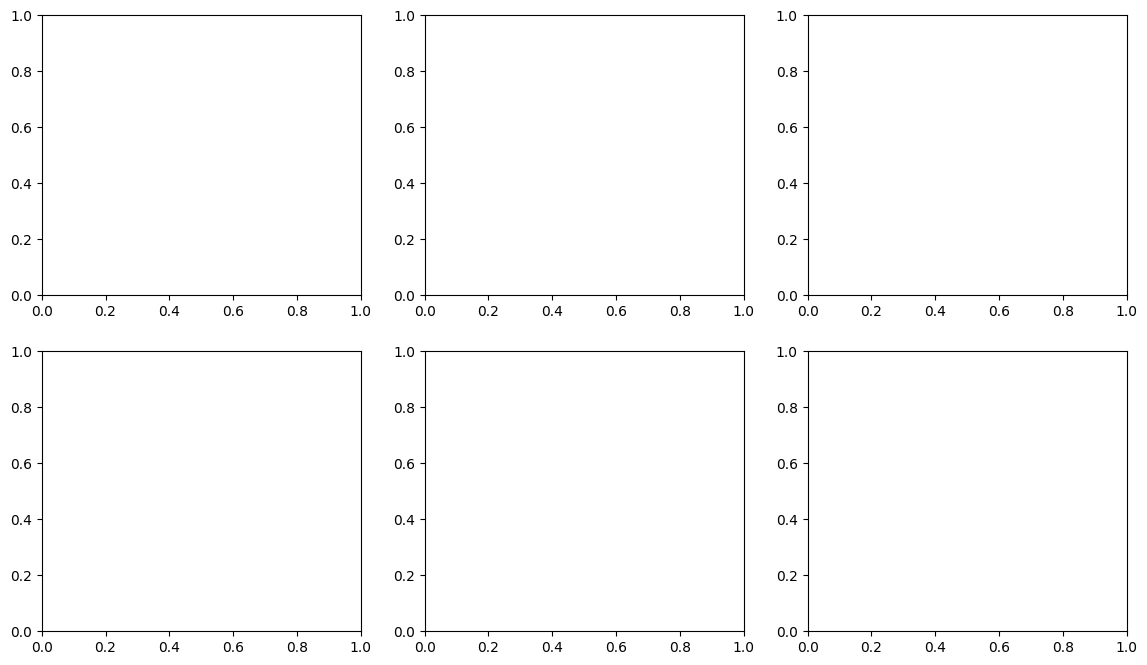

In [24]:
fig,axes = plt.subplots(2,3,figsize=(14,8)) 
axes= axes.flatten()

for i , name in enumerate(df_results['Model']):
  cm= confusion_matrix(y_test,predictions_dict[name])
  sns.heatmap(cm,annot=True,cmap="RdPu",fmt='d',cbar=False,ax=axes[i],xticklabels=["No Churn","Churn"],yticklabels=["No Churn","Churn"])
  axes[i].set_title(name,fontweight="bold")
  axes[i].set_xlabel("Predicted")
  axes[i].set_ylabel("Actual")
plt.suptitle("Confusion Matrix - All Classifier",fontsize=14,fontweight="bold")
plt.tight_layout()
plt.show()

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8, 6))

# Simple loop over each model to plot its ROC curve
for name in df_results["Model"]:
    proba = probabilities_dict[name]
    
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    
    # Plots each line with its calculated Area Under the Curve (AUC)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc:.3f})")

# Add the baseline diagonal for reference
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random Classifier (AUC = 0.500)")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Classifier Comparison", fontsize=13, fontweight="bold")
plt.legend(loc="lower right", fontsize=9)
plt.grid(linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'df_results' is not defined

<Figure size 800x600 with 0 Axes>

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

plt.figure(figsize=(8, 6))

# Loop over each model to plot its Precision-Recall curve
for name in df_results["Model"]:
    proba = probabilities_dict[name]
    
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, proba)
    pr_auc = auc(recall_vals, precision_vals)
    
    # Plotting Precision on Y-axis and Recall on X-axis
    plt.plot(recall_vals, precision_vals, lw=2, label=f"{name} (PR-AUC = {pr_auc:.3f})")

plt.xlabel("Recall (True Positive Rate)")
plt.ylabel("Precision (Positive Predictive Value)")
plt.title("Precision-Recall Curves — Classifier Comparison", fontsize=13, fontweight="bold")
plt.legend(loc="lower left", fontsize=9)
plt.grid(linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'df_results' is not defined

<Figure size 800x600 with 0 Axes>

In [21]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
# We remove class_weight='balanced' because SMOTE will balance the data arrays directly
models_for_smote = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Naive Bayes": GaussianNB(),
    "Support Vector Classifier": SVC(random_state=42),
    "KNN Classifier": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)}

ModuleNotFoundError: No module named 'imblearn'

In [22]:
results_smote = []

for name, model in models_for_smote.items():
    # Construct the imblearn pipeline
    pipeline = ImbPipeline(steps=[
        ("preprocessor", preprocessor), 
        ("smote", SMOTE(random_state=42)), # Synthetically balances X_train in real-time
        ("model", model)
    ])

    # Fit pipeline (SMOTE runs on X_train, but is automatically ignored for X_test!)
    pipeline.fit(X_train, y_train)

    # Predict discrete classes
    y_pred = pipeline.predict(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results_smote.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

# Render SMOTE summary table
df_smote_results = pd.DataFrame(results_smote).sort_values(by="F1-Score", ascending=False)
df_smote_results.head(len(models_for_smote))

NameError: name 'models_for_smote' is not defined